In [ ]:
#Show B field for checker board array
!pip install magpylib
import matplotlib.pyplot as plt

import numpy as np

import magpylib as magpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 17.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


###Halbach cylinder of the two magnets visualisation

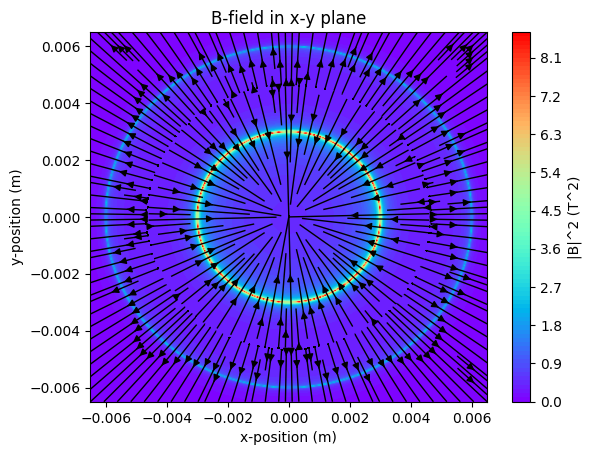

[[-0.04023268 -0.04058294 -0.0409359  ... -0.0409359  -0.04058294
  -0.04023268]
 [-0.04058294 -0.04093769 -0.04129518 ... -0.04129518 -0.04093769
  -0.04058294]
 [-0.0409359  -0.04129518 -0.04165724 ... -0.04165724 -0.04129518
  -0.0409359 ]
 ...
 [-0.0409359  -0.04129518 -0.04165724 ... -0.04165724 -0.04129518
  -0.0409359 ]
 [-0.04058294 -0.04093769 -0.04129518 ... -0.04129518 -0.04093769
  -0.04058294]
 [-0.04023268 -0.04058294 -0.0409359  ... -0.0409359  -0.04058294
  -0.04023268]]


In [ ]:
#from loguru import logger
#from magpylib_material_response.demag import apply_demag
#from magpylib_material_response.meshing import mesh_all

## all dimensions in metre
L=3e-3
mh=3.0e-3 #height
md=6.0e-3 #diameter
r1=3.0e-3
r2=6.0e-3

phi1=0
phi2=360
## ensure the full ring

# Create a Matplotlib figure
fig, ax = plt.subplots()

# Create an observer grid in the xz-symmetry plane
ts = np.linspace(-6.5e-3, 6.5e-3, 400)
grid = np.array([[(x, y, mh/2+3e-6) for x in ts] for y in ts])
## z-cooridnate fixed slightly above the magnet top surface
remanence=1.44

inside_cylinder = magpy.magnet.Cylinder(polarization=(0,0,-remanence), dimension=(md,mh), position = (0,0,0)) ## downwards polarisation
outside_cylinder = magpy.magnet.CylinderSegment(polarization=(0,0,remanence), dimension=(r1,r2,mh,phi1,phi2), position = (0,0,0)) # upwards polarization


# combine both magnet into a collection object
c=magpy.Collection(inside_cylinder,outside_cylinder)#.rotate_from_angax(0, 'z')
# c=magpy.Collection(cube1,cube2,cube3,cube4,cube5,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,)#,cube13,cube14,cube15,cube16,cube17,cube18,cube19,cube20,cube21).rotate_from_angax(0, 'z')

#,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,cube14,cube15,cube16,cube17,cube18,cube19,cube20,cube21
#cube5,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,cube14,
    #cube15,cube16,cube17,cube18,cube19,cube20,cube21,cube22,cube23,cube24,cube25,cube26,cube27,cube28,cube29


B = c.getB(grid) ## getB() calculated the B field of all grid points
log10_norm_B = np.log10(np.linalg.norm(B, axis=2)) ## log 10 to maje the field vary over many orders of magnitude
normB = np.linalg.norm(B, axis=2)  ##compute magnitude

#print(grid[0,:,:])
#print(grid[1,:,:])
#print(grid[:,:,2])
#print(B[:,:,2])
# Display the B-field with streamplot using log10-scaled
# color function and linewidth

# Add colorbar with logarithmic labels
#cb = fig.colorbar(splt.lines, ax=ax, label="|B| (mT)")
#ticks = np.array([3, 10, 30, 100, 300])
#cb.set_ticks(np.log10(ticks))
#cb.set_ticklabels(ticks)

#contour plot creation

cp = ax.contourf(
    grid[:, :, 0], #for every value in the first and second axes, take just the zeroth element in the third axis.
    grid[:, :, 1],
    #normB,
    np.square(B[:,:,2])+np.square(B[:,:,0])+np.square(B[:,:,1]),
    cmap="rainbow",
    levels=100,  #100 contour levels
    zorder=1,  #places this plot at the bottom if it is overlaid with other plot element
)

splt = ax.streamplot(
    grid[:, :, 0],
    grid[:, :, 1],
    B[:, :, 0],
    B[:, :, 1],
    color="k",
    density=2,
    linewidth=1,
    zorder=3,
)
# Add colorbar
fig.colorbar(cp, ax=ax, label="|B|^2 (T^2)")
# Outline magnet boundary
#x.plot(
#   [-2e-3, -2e-3, 0, 0,0,2e-3,2e-3,0,-2e-3,-2e-3,2e-3],
#   [-2e-3, 2e-3, 2e-3, -2e-3,2e-3,2e-3,-2e-3,-2e-3,-2e-3,0,0],
#   'k--',
#   lw=2,
#
#
# Figure styling
ax.set(
  xlabel="x-position (m)",
  ylabel="y-position (m)",
  )
plt.title("B-field in x-y plane")
plt.savefig("B-field in x-y plane", format="pdf", bbox_inches="tight")
plt.savefig("B-field-in-x-y-plane.png", format="png", dpi=400, bbox_inches="tight")
plt.tight_layout
plt.show()
print(B[:,:,2])

## using B^2 to highlight regions with the magnetic energy

magpy.show(c, backend='plotly', style_legend_show=False)

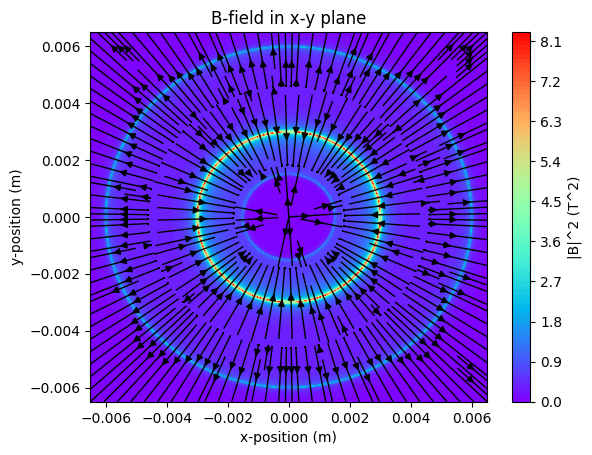

[[-0.04298131 -0.04335053 -0.04372257 ... -0.04372257 -0.04335053
  -0.04298131]
 [-0.04335053 -0.04372446 -0.04410125 ... -0.04410125 -0.04372446
  -0.04335053]
 [-0.04372257 -0.04410125 -0.04448284 ... -0.04448284 -0.04410125
  -0.04372257]
 ...
 [-0.04372257 -0.04410125 -0.04448284 ... -0.04448284 -0.04410125
  -0.04372257]
 [-0.04335053 -0.04372446 -0.04410125 ... -0.04410125 -0.04372446
  -0.04335053]
 [-0.04298131 -0.04335053 -0.04372257 ... -0.04372257 -0.04335053
  -0.04298131]]


In [ ]:
#### new ring geometry
#from loguru import logger
#from magpylib_material_response.demag import apply_demag
#from magpylib_material_response.meshing import mesh_all

## all dimensions in metre
L=3e-3
mh=3.0e-3 #height
md=6.0e-3 #diameter
r1=3.0e-3
r2=6.0e-3

phi1=0
phi2=360
## ensure the full ring

# Create a Matplotlib figure
fig, ax = plt.subplots()

# Create an observer grid in the xz-symmetry plane
ts = np.linspace(-6.5e-3, 6.5e-3, 400)
grid = np.array([[(x, y, mh/2+3e-6) for x in ts] for y in ts])
## z-cooridnate fixed slightly above the magnet top surface
remanence=1.44

inside_cylinder = magpy.magnet.CylinderSegment(polarization=(0,0,-remanence), dimension=(1.5e-3, 3.0e-3, mh, 0, 360), position=(0,0,0)) ## downwards polarisation
outside_cylinder = magpy.magnet.CylinderSegment(polarization=(0,0,remanence), dimension=(r1,r2,mh,phi1,phi2), position = (0,0,0)) # upwards polarization


# combine both magnet into a collection object
c=magpy.Collection(inside_cylinder,outside_cylinder)#.rotate_from_angax(0, 'z')
# c=magpy.Collection(cube1,cube2,cube3,cube4,cube5,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,)#,cube13,cube14,cube15,cube16,cube17,cube18,cube19,cube20,cube21).rotate_from_angax(0, 'z')

#,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,cube14,cube15,cube16,cube17,cube18,cube19,cube20,cube21
#cube5,cube6,cube7,cube8,cube9,cube10,cube11,cube12,cube13,cube14,
    #cube15,cube16,cube17,cube18,cube19,cube20,cube21,cube22,cube23,cube24,cube25,cube26,cube27,cube28,cube29


B = c.getB(grid) ## getB() calculated the B field of all grid points
log10_norm_B = np.log10(np.linalg.norm(B, axis=2)) ## log 10 to maje the field vary over many orders of magnitude
normB = np.linalg.norm(B, axis=2)  ##compute magnitude

#print(grid[0,:,:])
#print(grid[1,:,:])
#print(grid[:,:,2])
#print(B[:,:,2])
# Display the B-field with streamplot using log10-scaled
# color function and linewidth

# Add colorbar with logarithmic labels
#cb = fig.colorbar(splt.lines, ax=ax, label="|B| (mT)")
#ticks = np.array([3, 10, 30, 100, 300])
#cb.set_ticks(np.log10(ticks))
#cb.set_ticklabels(ticks)

#contour plot creation

cp = ax.contourf(
    grid[:, :, 0], #for every value in the first and second axes, take just the zeroth element in the third axis.
    grid[:, :, 1],
    #normB,
    np.square(B[:,:,2])+np.square(B[:,:,0])+np.square(B[:,:,1]),
    cmap="rainbow",
    levels=100,  #100 contour levels
    zorder=1,  #places this plot at the bottom if it is overlaid with other plot element
)

splt = ax.streamplot(
    grid[:, :, 0],
    grid[:, :, 1],
    B[:, :, 0],
    B[:, :, 1],
    color="k",
    density=2,
    linewidth=1,
    zorder=3,
)
# Add colorbar
fig.colorbar(cp, ax=ax, label="|B|^2 (T^2)")
# Outline magnet boundary
#x.plot(
#   [-2e-3, -2e-3, 0, 0,0,2e-3,2e-3,0,-2e-3,-2e-3,2e-3],
#   [-2e-3, 2e-3, 2e-3, -2e-3,2e-3,2e-3,-2e-3,-2e-3,-2e-3,0,0],
#   'k--',
#   lw=2,
#
#
# Figure styling
ax.set(
  xlabel="x-position (m)",
  ylabel="y-position (m)",
  )
plt.title("B-field in x-y plane")

plt.tight_layout
plt.show()
print(B[:,:,2])

## using B^2 to highlight regions with the magnetic energy

magpy.show(c, backend='plotly', style_legend_show=False)

In [ ]:
### to visualise where exactly the field hits maximum

# choose metric: magnitude-squared is faster and matches your contour
B2 = np.einsum('ijk,ijk->ij', B, B)          # shape (Ny,Nx)

# global maximum in the plane
jmax, imax = np.unravel_index(np.argmax(B2), B2.shape)
x_max = grid[jmax, imax, 0]
y_max = grid[jmax, imax, 1]
r_max = np.hypot(x_max, y_max)
Bvec_max = B[jmax, imax, :]
Bmag_max = np.sqrt(B2[jmax, imax])

print(f"Global |B| max at (x, y) = ({x_max:.6e}, {y_max:.6e}) m")
print(f"Radius r = {r_max:.6e} m, |B| = {Bmag_max:.6e} T, B = {Bvec_max}")

# maxima restricted to x- and y-axes (y=0 or x=0 slices)
# find indices closest to 0 along each axis in your symmetric ts grid
iy0 = np.argmin(np.abs(ts - 0.0))   # row where y≈0 (x-axis)
ix0 = np.argmin(np.abs(ts - 0.0))   # column where x≈0 (y-axis)

# along x-axis (y≈0): vary x, keep y fixed
i_xaxis = np.argmax(B2[iy0, :])
xmax_on_xaxis = grid[iy0, i_xaxis, 0]
rmax_on_xaxis = np.abs(xmax_on_xaxis)
Bmax_on_xaxis = np.sqrt(B2[iy0, i_xaxis])
print(f"Max along x-axis (y=0): x = {xmax_on_xaxis:.6e} m, r = {rmax_on_xaxis:.6e} m, |B| = {Bmax_on_xaxis:.6e} T")

# along y-axis (x≈0): vary y, keep x fixed
j_yaxis = np.argmax(B2[:, ix0])
ymax_on_yaxis = grid[j_yaxis, ix0, 1]
rmax_on_yaxis = np.abs(ymax_on_yaxis)
Bmax_on_yaxis = np.sqrt(B2[j_yaxis, ix0])
print(f"Max along y-axis (x=0): y = {ymax_on_yaxis:.6e} m, r = {rmax_on_yaxis:.6e} m, |B| = {Bmax_on_yaxis:.6e} T")


Global |B| max at (x, y) = (-2.003759e-03, -2.231830e-03) m
Radius r = 2.999352e-03 m, |B| = 2.878132e+00 T, B = [ 1.91682736  2.13500284 -0.22622466]
Max along x-axis (y=0): x = 3.013784e-03 m, r = 3.013784e-03 m, |B| = 2.219256e+00 T
Max along y-axis (x=0): y = 3.013784e-03 m, r = 3.013784e-03 m, |B| = 2.219256e+00 T


###Varying different parameter to see levitation ehight

In [ ]:
# z-plane range (meters)
z_planes = np.linspace(0.0001, 0.002, 100)  # 0.1 mm to 2 mm above magnet top, so we find optimum place to put the ring

###constants
chi_xy = -85e-6
chi_z = -450e-6  #graphite is anisotropic, stronger diamagnetism along z-axis
mu0 = 4*3.141592653589793*1e-7
g=9.81        #gravity
rho=2070      #density of graphite
remanence=1.44

#ring parameters
r_inner = 3e-3
r_outer = 3.5e-3
delta = 1.1e-3

# Integration grid (meters)
xi = np.linspace(-r_outer, r_outer, 400)
yi = np.linspace(-r_outer, r_outer, 400)
X, Y = np.meshgrid(xi, yi)
mask = (np.sqrt(X**2 + Y**2) >= r_inner) & (np.sqrt(X**2 + Y**2) <= r_outer)

def compute_B_slices(collection, xi, yi, z_planes):
    """Precompute and store B-field slices for given spatial grids."""
    B_slices = []
    grid_xy = np.array([[(x, y, 0) for x in xi] for y in yi])  # base grid shape (ny,nx,3)
    for z in z_planes:
        grid = grid_xy.copy()
        grid[:,:,2] = z
        B = c.getB(grid)
        B_slices.append(B)
    return np.array(B_slices)  # shape (nz, ny, nx, 3)

B_slices = compute_B_slices(c, xi, yi, z_planes)

In [ ]:
def compute_Umag_thick(B_stack, mask, chi_xy, chi_z, mu0, xi, yi, dz):
    Umag_total = 0
    for B_slice in B_stack:
        Bx, By, Bz = B_slice[...,0], B_slice[...,1], B_slice[...,2]
        u_density = -(1/(2*mu0)) * (chi_xy * (Bx**2 + By**2) + chi_z * Bz**2)
        u_density[~mask] = 0
        u_density[np.isnan(u_density)] = 0
        Umag_total += dz * np.trapezoid(np.trapezoid(u_density, dx=yi[1]-yi[0], axis=1), dx=xi[1]-xi[0], axis=0)
    return Umag_total

m_ring=8.469633263113159e-05


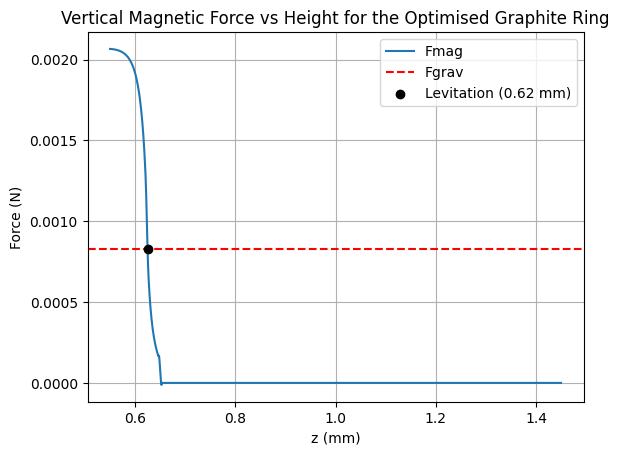

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# Parameters
r_in = 7e-3        # inner radius of ring (m)
r_out = 7.8e-3     # outer radius of ring (m)
thickness_ring = 1.1e-3  # graphite thickness (m)

r_calcite = 3e-3   # radius of calcite (m)
thickness_calcite = 0.1e-3    # calcite thickness (m)

rho_graphite = 2.07e3  # density graphite (kg/m^3)
rho_calcite = 2.71e3  # density calcite (kg/m^3)
g = 9.81              # gravity (m/s^2)

# Calculate masses
V_ring = np.pi * (r_out**2 - r_in**2) * thickness_ring
m_ring = rho_graphite * V_ring

V_calcite = np.pi * r_calcite**2 * thickness_calcite
m_calcite = rho_calcite * V_calcite

m_total = m_ring
Fgrav = m_total * g

# z-plane setup
z_planes = np.linspace(0.000, 0.002, 2000)
dz = z_planes[1] - z_planes[0]
nz = len(z_planes)

# Magnetic energy calculation
Umag_array = []
delta_obj = thickness_ring  # assuming vertical mask covers only ring
margin = int(np.ceil((delta_obj/2)/dz))
for i in range(margin, nz - margin):
    lower = i - margin
    upper = i + margin
    B_subset = B_slices[lower:upper+1]
    Umag_val = compute_Umag_thick(B_subset, mask, chi_xy, chi_z, mu0, xi, yi, dz)
    Umag_array.append(Umag_val)

Umag_array = np.array(Umag_array)
z_centers = z_planes[margin:nz-margin]
Umag_interp = interp1d(z_centers, Umag_array, kind='cubic', fill_value="extrapolate")
z_fine = np.linspace(z_centers[0], z_centers[-1], 2000)
Umag_fine = Umag_interp(z_fine)

# Fmag calculation by energy gradient
Umag_fine_smooth = savgol_filter(Umag_fine, window_length=15, polyorder=3)
Fmag_fine = -np.gradient(Umag_fine_smooth, z_fine)

idx_eq = np.argmin(np.abs(Fmag_fine - Fgrav))
ze = z_fine[idx_eq]

print(f"m_ring={m_ring}")

plt.plot(z_fine*1e3, Fmag_fine, label="Fmag")
plt.axhline(Fgrav, color='r', linestyle='--', label="Fgrav")
plt.scatter(ze*1e3, Fgrav, color='k', zorder=5, label=f"Levitation ({ze*1e3:.2f} mm)")
plt.xlabel("z (mm)")
plt.ylabel("Force (N)")
plt.title("Vertical Magnetic Force vs Height for the Optimised Graphite Ring")
plt.legend()
plt.grid(True)
plt.savefig("Fmag vs Fgrav.png", format="png", dpi=400, bbox_inches="tight")
plt.show()


Levitation height z_e = 0.637 mm (Fmag = Fgrav = 3.03e-04 N)


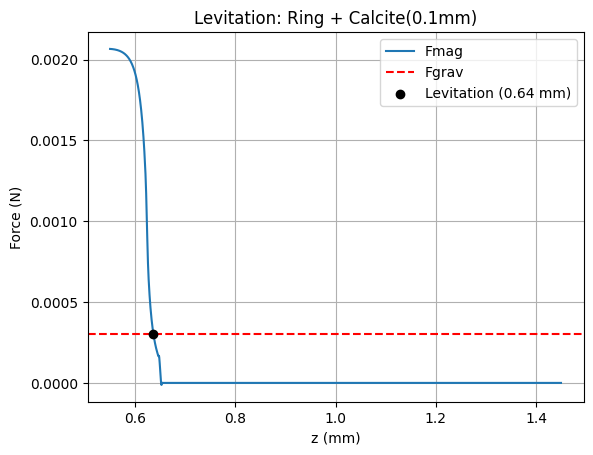

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

# Parameters
r_in = 3e-3        # inner radius of ring (m)
r_out = 3.5e-3     # outer radius of ring (m)
thickness_ring = 1.1e-3  # graphite thickness (m)

r_calcite = 3e-3   # radius of calcite (m)
thickness_calcite = 0.1e-3    # calcite thickness (m)

rho_graphite = 2.07e3  # density graphite (kg/m^3)
rho_calcite = 2.71e3  # density calcite (kg/m^3)
g = 9.81              # gravity (m/s^2)

# Calculate masses
V_ring = np.pi * (r_out**2 - r_in**2) * thickness_ring
m_ring = rho_graphite * V_ring

V_calcite = np.pi * r_calcite**2 * thickness_calcite
m_calcite = rho_calcite * V_calcite

m_total = m_ring + m_calcite
Fgrav = m_total * g

# z-plane setup
z_planes = np.linspace(0.000, 0.002, 2000)
dz = z_planes[1] - z_planes[0]
nz = len(z_planes)

# Magnetic energy calculation
Umag_array = []
delta_obj = thickness_ring  # assuming vertical mask covers only ring
margin = int(np.ceil((delta_obj/2)/dz))
for i in range(margin, nz - margin):
    lower = i - margin
    upper = i + margin
    B_subset = B_slices[lower:upper+1]
    Umag_val = compute_Umag_thick(B_subset, mask, chi_xy, chi_z, mu0, xi, yi, dz)
    Umag_array.append(Umag_val)

Umag_array = np.array(Umag_array)
z_centers = z_planes[margin:nz-margin]
Umag_interp = interp1d(z_centers, Umag_array, kind='cubic', fill_value="extrapolate")
z_fine = np.linspace(z_centers[0], z_centers[-1], 2000)
Umag_fine = Umag_interp(z_fine)

# Fmag calculation by energy gradient
Umag_fine_smooth = savgol_filter(Umag_fine, window_length=15, polyorder=3)
Fmag_fine = -np.gradient(Umag_fine_smooth, z_fine)

idx_eq = np.argmin(np.abs(Fmag_fine - Fgrav))
ze = z_fine[idx_eq]

print(f"Levitation height z_e = {ze*1e3:.3f} mm (Fmag = Fgrav = {Fgrav:.2e} N)")

plt.plot(z_fine*1e3, Fmag_fine, label="Fmag")
plt.axhline(Fgrav, color='r', linestyle='--', label="Fgrav")
plt.scatter(ze*1e3, Fgrav, color='k', zorder=5, label=f"Levitation ({ze*1e3:.2f} mm)")
plt.xlabel("z (mm)")
plt.ylabel("Force (N)")
plt.title("Levitation: Ring + Calcite(0.1mm)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print (m_ring)

2.3248571034727877e-05


In [ ]:
print (m_calcite)

7.662344482105505e-06


# With piece of glass

### Trap stiffness and trap frequency

#### K_z


Vertical trap stiffness at equilibrium:
  k_z = 20.561 N/m
  at z_equilibrium = 0.637 mm


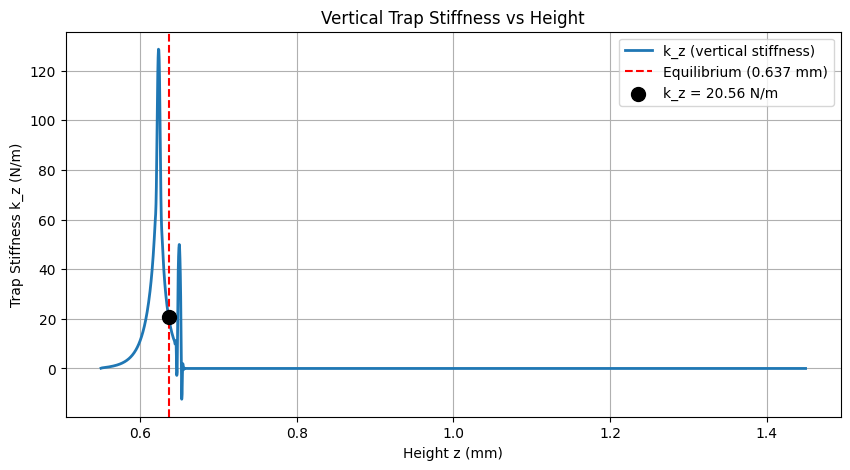

In [ ]:
# Calculate second derivative of force (stiffness k_z)
# kz = -dF/dz
k_z = -np.gradient(Fmag_fine, z_fine)  # Stiffness in N/m

# Find stiffness at equilibrium position
k_z_eq = k_z[idx_eq]

print(f"\nVertical trap stiffness at equilibrium:")
print(f"  k_z = {k_z_eq:.3f} N/m")
print(f"  at z_equilibrium = {ze*1e3:.3f} mm")

# Plot stiffness vs height
plt.figure(figsize=(10, 5))
plt.plot(z_fine*1e3, k_z, label="k_z (vertical stiffness)", linewidth=2)
plt.axvline(ze*1e3, color='r', linestyle='--', label=f"Equilibrium ({ze*1e3:.3f} mm)")
plt.scatter(ze*1e3, k_z_eq, color='k', s=100, zorder=5, label=f"k_z = {k_z_eq:.2f} N/m")
plt.xlabel("Height z (mm)")
plt.ylabel("Trap Stiffness k_z (N/m)")
plt.title("Vertical Trap Stiffness vs Height")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# trap frequency fz
omega_z = np.sqrt(k_z_eq / m_ring)  # Angular frequency (rad/s)
f_z = omega_z / (2 * np.pi)          # Frequency (Hz)
T_z = 1 / f_z                         # Period (seconds)

print(f"\nVertical oscillation (z-direction):")
print(f"  Frequency: f_z = {f_z:.2f} Hz")
print(f"  Period: T_z = {T_z*1000:.1f} ms")
print(f"  Angular frequency: ω_z = {omega_z:.2f} rad/s")



Vertical oscillation (z-direction):
  Frequency: f_z = 149.67 Hz
  Period: T_z = 6.7 ms
  Angular frequency: ω_z = 940.43 rad/s


#### K_x

In [ ]:
x_fine = np.linspace(-0.0005, 0.0005, 1000)
Fx_fine = np.zeros_like(x_fine)
B_squared_x = np.zeros_like(x_fine)

# Loop over x positions (same structure as your z loop)
for i, x_pos in enumerate(x_fine):
    # Observation position: (x_pos, 0, ze)
    # Note: y=0 (center), z=ze (equilibrium height from your calculation)
    obs = np.array([[x_pos, 0, ze]])


    B = c.getB(obs)

    # Calculate B² = Bx² + By² + Bz²
    B_squared_x[i] = np.sum(B**2)

# Calculate gradient of B² with respect to x
dB2_dx = np.gradient(B_squared_x, x_fine)

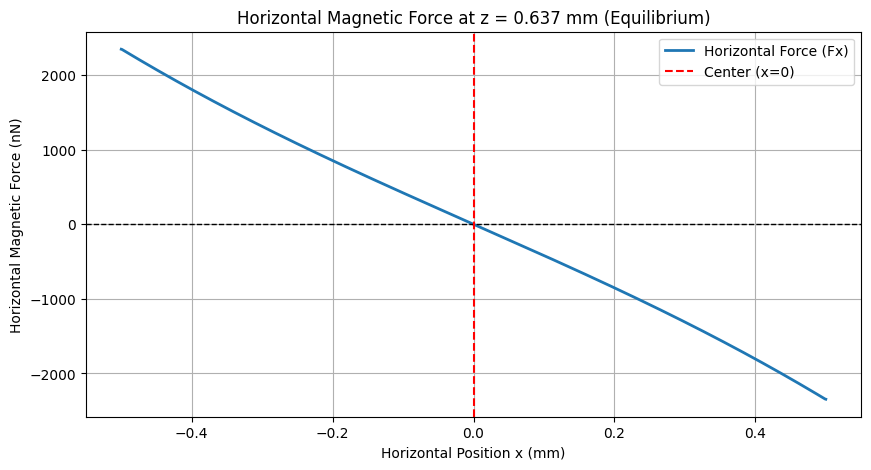


Horizontal trap stiffness at equilibrium:
  k_x = 0.004 N/m
  at x = 0 mm (center)
  at z = 0.637 mm (equilibrium height)


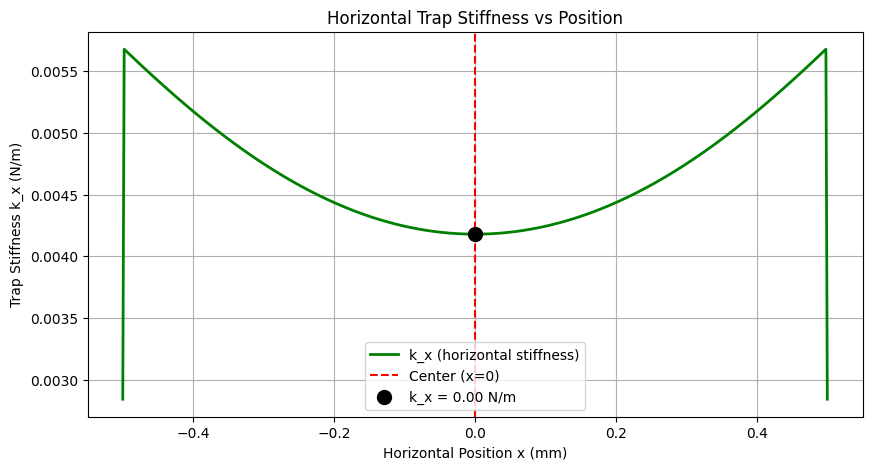

In [ ]:
# Magnetic force in x-direction
###define from before
chi_xy = -85e-6
chi_z = -450e-6  #graphite is anisotropic, stronger diamagnetism along z-axis

Fx_fine = (chi_xy * V_ring) / (2 * mu0) * dB2_dx

plt.figure(figsize=(10, 5))
plt.plot(x_fine*1e3, Fx_fine*1e9, linewidth=2, label='Horizontal Force (Fx)')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.axvline(0, color='r', linestyle='--', label='Center (x=0)')
plt.xlabel("Horizontal Position x (mm)")
plt.ylabel("Horizontal Magnetic Force (nN)")
plt.title(f"Horizontal Magnetic Force at z = {ze*1e3:.3f} mm (Equilibrium)")
plt.legend()
plt.grid(True)
plt.show()

#k_x = -dF_x/dx
k_x = -np.gradient(Fx_fine, x_fine)

# Find stiffness at center (x=0)
idx_x_center = np.argmin(np.abs(x_fine))
k_x_eq = k_x[idx_x_center]

print(f"\nHorizontal trap stiffness at equilibrium:")
print(f"  k_x = {k_x_eq:.3f} N/m")
print(f"  at x = 0 mm (center)")
print(f"  at z = {ze*1e3:.3f} mm (equilibrium height)")

plt.figure(figsize=(10, 5))
plt.plot(x_fine*1e3, k_x, label="k_x (horizontal stiffness)", linewidth=2, color='green')
plt.axvline(0, color='r', linestyle='--', label=f"Center (x=0)")
plt.scatter(0, k_x_eq, color='k', s=100, zorder=5, label=f"k_x = {k_x_eq:.2f} N/m")
plt.xlabel("Horizontal Position x (mm)")
plt.ylabel("Trap Stiffness k_x (N/m)")
plt.title("Horizontal Trap Stiffness vs Position")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Horizontal oscillation frequency
omega_x = np.sqrt(k_x_eq / m_total)  # Angular frequency (rad/s)
f_x = omega_x / (2 * np.pi)          # Frequency (Hz)
T_x = 1 / f_x                         # Period (seconds)

print(f"\nHorizontal oscillation (x-direction):")
print(f"  Frequency: f_x = {f_x:.2f} Hz")
print(f"  Period: T_x = {T_x*1000:.2f} ms")
print(f"  Angular frequency: ω_x = {omega_x:.2f} rad/s")


Horizontal oscillation (x-direction):
  Frequency: f_x = 1.85 Hz
  Period: T_x = 540.37 ms
  Angular frequency: ω_x = 11.63 rad/s


#### Summary of f_z and f_x

In [ ]:

print(f"\nVertical (z-direction):")
print(f"  Stiffness: k_z = {k_z_eq:.3f} N/m")
print(f"  Frequency: f_z = {f_z:.2f} Hz")
print(f"  Period: T_z = {T_z*1000:.2f} ms")

print(f"\nHorizontal (x-direction):")
print(f"  Stiffness: k_x = {k_x_eq:.3f} N/m")
print(f"  Frequency: f_x = {f_x:.2f} Hz")
print(f"  Period: T_x = {T_x*1000:.2f} ms")

print(f"\nRatios:")
print(f"  k_z/k_x = {k_z_eq/k_x_eq:.2f}")
print(f"  f_z/f_x = {f_z/f_x:.2f}")


Vertical (z-direction):
  Stiffness: k_z = 20.561 N/m
  Frequency: f_z = 149.67 Hz
  Period: T_z = 6.68 ms

Horizontal (x-direction):
  Stiffness: k_x = 0.004 N/m
  Frequency: f_x = 1.85 Hz
  Period: T_x = 540.37 ms

Ratios:
  k_z/k_x = 4919.97
  f_z/f_x = 80.88


### Moment of inertia

In [ ]:
# ============================================================================
# MOMENT OF INERTIA CALCULATION
# ============================================================================

print("\n" + "="*60)
print("CALCULATING MOMENT OF INERTIA")
print("="*60)

# Ring spinning about vertical axis (z)
I_z_ring = 0.5 * m_ring * (r_inner**2 + r_outer**2)

# Calcite disk spinning about center
I_z_calcite = 0.5 * m_calcite * r_calcite**2

# Total moment of inertia
I_z_total = I_z_ring + I_z_calcite

print(f"\nMoment of inertia (spinning about z-axis):")
print(f"  Ring: I_z = {I_z_ring*1e9:.3f} × 10⁻⁹ kg·m²")
print(f"  Calcite: I_z = {I_z_calcite*1e9:.3f} × 10⁻⁹ kg·m²")
print(f"  Total: I_z = {I_z_total*1e9:.3f} × 10⁻⁹ kg·m²")

# Tilting about horizontal axis (x or y)
I_tilt_ring = 0.25 * m_ring * (r_inner**2 + r_outer**2) + (1/12) * m_ring * thickness_ring**2
I_tilt_calcite = 0.25 * m_calcite * r_calcite**2 + (1/12) * m_calcite * thickness_calcite**2
I_tilt_total = I_tilt_ring + I_tilt_calcite

print(f"\nMoment of inertia (tilting about diameter):")
print(f"  Total: I_tilt = {I_tilt_total*1e9:.3f} × 10⁻⁹ kg·m²")



CALCULATING MOMENT OF INERTIA

Moment of inertia (spinning about z-axis):
  Ring: I_z = 0.247 × 10⁻⁹ kg·m²
  Calcite: I_z = 0.034 × 10⁻⁹ kg·m²
  Total: I_z = 0.281 × 10⁻⁹ kg·m²

Moment of inertia (tilting about diameter):
  Total: I_tilt = 0.143 × 10⁻⁹ kg·m²
